In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Serie de tiempo obtenida de: https://ideam.gov.co/dhime?utm_source=chatgpt.com
df = pd.read_csv('datos_meteorologicos.csv', parse_dates=['Fecha'])
df = df.sort_values('Fecha').set_index('Fecha')
df.head()

,CodigoEstacion,NombreEstacion,Variable,Parametro,Unidad,Valor,NivelAprobacion
Fecha,,,,,,,
2015-10-05,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo
2015-10-06,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo
2015-10-07,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo
2015-10-08,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.5,Definitivo
2015-10-09,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo


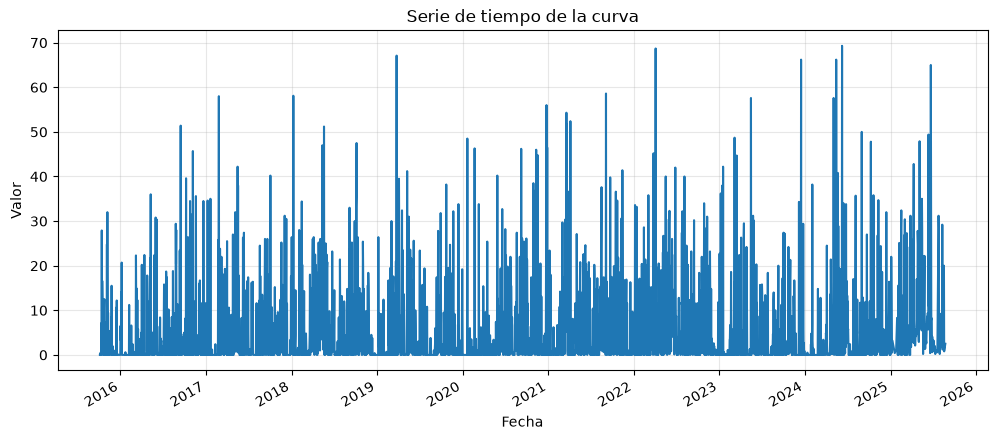

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
df['Valor'].plot(ax=ax)
ax.set_title('Serie de tiempo de la curva')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor')
ax.grid(True, alpha=0.3)
plt.show()

Se van a considerar los siguientes umbrales para definir el estado del clima
$$
X_t =
\begin{cases}
0 & R_t < 0.1 & \text{Seco}\\
1 & 0.1\leq R_t<5 & \text{Lluvia ligera}\\
2 & 5\leq R_t<20 & \text{Lluvia moderada}\\
3 & R_t\geq20 & \text{Lluvia fuerte}
\end{cases}
$$


In [3]:
df['estado']= pd.cut(df['Valor'], bins=[-float('inf'), 0.1, 5.0, 20.0, float('inf')], labels=['Seco', 'Lluvia ligera', 'Lluvia moderada','Lluvia fuerte'])
df['estado_numérico']= df['estado'].map({'Seco': 0, 'Lluvia ligera': 1, 'Lluvia moderada': 2, 'Lluvia fuerte': 3}).astype('Int64')
df.head()


,CodigoEstacion,NombreEstacion,Variable,Parametro,Unidad,Valor,NivelAprobacion,estado,estado_numérico
Fecha,,,,,,,,,
2015-10-05,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo,Seco,0
2015-10-06,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo,Seco,0
2015-10-07,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo,Seco,0
2015-10-08,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.5,Definitivo,Lluvia ligera,1
2015-10-09,27015330,AEROPUERTO OLAYA HERRERA [27015330],PRECIPITACION,Día pluviométrico (convencional),mm,0.0,Definitivo,Seco,0


### Matriz de probabilidades de transicion

La entrada $P_{ij}$ se estima dividiendo las transiciones de $i$ a $j$ entre todas las que salen de $i$. Las filas representan el estado anterior y las columnas el siguiente. Cada fila con observaciones suma 1; si no hay transiciones queda como NaN. Solo contamos dias consecutivos con estados completos.


In [4]:
import numpy as np
from IPython.display import display

estados = [0, 1, 2, 3]
serie = df['estado_numérico'].sort_index()
pares = pd.DataFrame({'previo': serie.shift(1), 'actual': serie})
dias_consecutivos = serie.index.to_series().diff().eq(pd.Timedelta(days=1))
pares = pares.loc[dias_consecutivos].dropna().astype(int)
conteos = pd.crosstab(pares['previo'], pares['actual']).reindex(index=estados, columns=estados, fill_value=0)
P = conteos.div(conteos.sum(axis=1).replace(0, np.nan), axis=0)
print('Matriz P: filas = estado anterior; columnas = estado siguiente')
display(P)


Matriz P: filas = estado anterior; columnas = estado siguiente


actual,0,1,2,3
previo,,,,
0,0.612430,0.215084,0.131285,0.041201
1,0.331767,0.344925,0.229323,0.093985
2,0.208447,0.392371,0.297003,0.102180
3,0.174074,0.385185,0.311111,0.129630


### Punto fijo y distribucion estacionaria

Una distribucion estacionaria es un vector fila $\pi$ que cumple $\pi P=\pi$, $\sum_i\pi_i=1$ y $\pi_i\geq0$. Representa las proporciones de largo plazo del modelo de transicion, no un estado individual que deje de cambiar. Resolvemos este sistema lineal y verificamos el punto fijo.

Tambien partimos de una distribucion concentrada en el estado 0 y calculamos $p_{t+1}=p_tP$. Para esta matriz, todas las entradas son positivas: la cadena es irreducible y aperiodica, por lo que tiene un unico equilibrio y converge a el desde cualquier estado inicial. En la serie meteorologica interpretamos estos resultados bajo el modelo definido por P.


Probabilidad estacionaria por estado:


,probabilidad_estacionaria
previo,
0,0.408395
1,0.304947
2,0.209771
3,0.076888


Error del punto fijo: 1.11e-16


,p_tras_100_pasos,pi
0,0.408395,0.408395
1,0.304947,0.304947
2,0.209771,0.209771
3,0.076888,0.076888


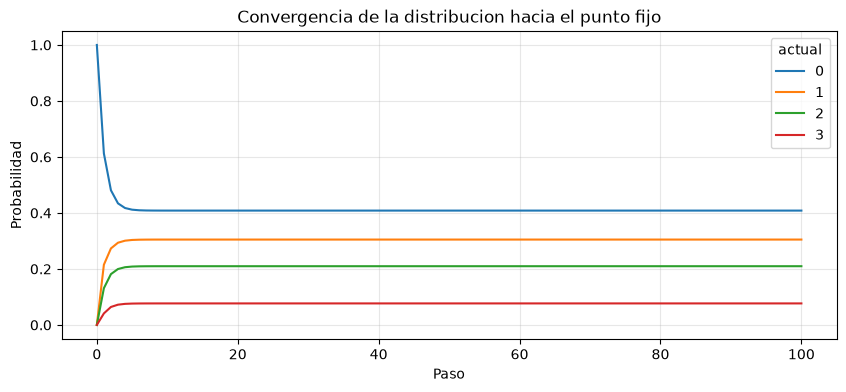

In [5]:
def validar_matriz(matriz):
    A = matriz.to_numpy(dtype=float)
    if A.shape[0] != A.shape[1] or not np.isfinite(A).all():
        raise ValueError('P debe ser cuadrada y tener probabilidades finitas.')
    if (A < 0).any() or not np.allclose(A.sum(axis=1), 1):
        raise ValueError('Las probabilidades deben ser no negativas y cada fila debe sumar 1.')
    if not matriz.index.equals(matriz.columns):
        raise ValueError('Filas y columnas deben tener los mismos estados en el mismo orden.')
    return A


def distribucion_estacionaria(matriz):
    A = validar_matriz(matriz)
    sistema = np.vstack([A.T - np.eye(len(A)), np.ones(len(A))])
    objetivo = np.r_[np.zeros(len(A)), 1.0]
    if np.linalg.matrix_rank(sistema) < len(A):
        raise ValueError('La matriz no tiene una distribucion estacionaria unica.')
    pi, *_ = np.linalg.lstsq(sistema, objetivo, rcond=None)
    if (pi < -1e-10).any():
        raise ValueError('No se obtuvo una distribucion estacionaria valida.')
    pi = np.maximum(pi, 0)
    pi /= pi.sum()
    if not np.allclose(pi @ A, pi):
        raise ValueError('La solucion no satisface el punto fijo.')
    return pd.Series(pi, index=matriz.index, name='probabilidad_estacionaria')


pi = distribucion_estacionaria(P)
print('Probabilidad estacionaria por estado:')
display(pi.to_frame())
print(f'Error del punto fijo: {np.max(np.abs(pi.to_numpy() @ P.to_numpy() - pi.to_numpy())):.2e}')

estado_inicial_equilibrio = 0
pasos_equilibrio = 100
p_inicial = np.zeros(len(P))
p_inicial[P.index.get_loc(estado_inicial_equilibrio)] = 1
evolucion = [p_inicial]
for _ in range(pasos_equilibrio):
    evolucion.append(evolucion[-1] @ P.to_numpy())
evolucion = pd.DataFrame(evolucion, columns=P.columns)
display(pd.DataFrame({'p_tras_100_pasos': evolucion.iloc[-1], 'pi': pi}))
ax = evolucion.plot(figsize=(10, 4))
ax.set_title('Convergencia de la distribucion hacia el punto fijo')
ax.set_xlabel('Paso')
ax.set_ylabel('Probabilidad')
ax.grid(True, alpha=0.3)
plt.show()


### Generacion de una secuencia seudoaleatoria

Elegimos un estado inicial y, en cada paso, sorteamos el siguiente estado usando las probabilidades de la fila correspondiente de P. Repetimos el procedimiento para obtener una cadena sintetica. La semilla permite reproducir exactamente la simulacion. Se generan estados discretos, no valores de precipitacion.

La secuencia generada sigue un modelo de primer orden por construccion. Sus frecuencias pueden aproximarse a $\pi$ al aumentar su longitud; no tienen que coincidir exactamente en una muestra finita. Descartamos los primeros 1000 pasos para reducir el efecto del estado inicial.


,estado
paso,
0,0
1,1
2,1
3,2
4,2
5,0
6,3
7,2
8,2


,pi,frecuencia_simulada
previo,,
0,0.408395,0.409510
1,0.304947,0.308521
2,0.209771,0.206866
3,0.076888,0.075103


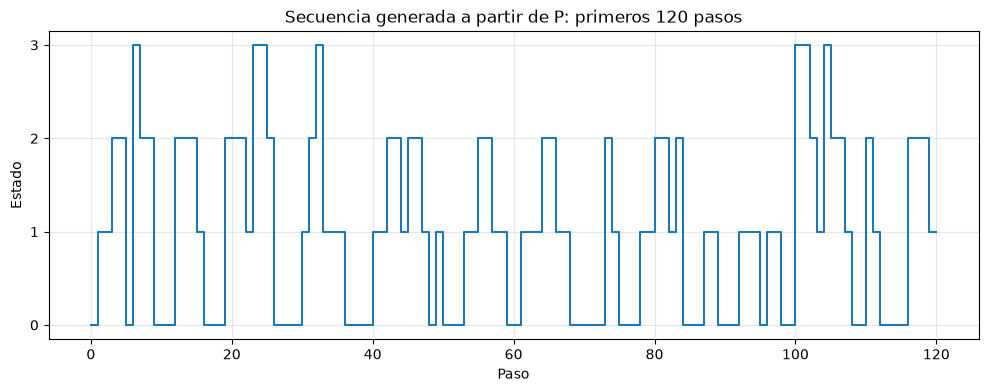

In [6]:
def simular_cadena(matriz, estado_inicial, n_pasos, semilla):
    A = validar_matriz(matriz)
    if estado_inicial not in matriz.index:
        raise ValueError('El estado inicial no pertenece a P.')
    if not isinstance(n_pasos, int) or n_pasos < 0:
        raise ValueError('n_pasos debe ser un entero no negativo.')
    rng = np.random.default_rng(semilla)
    etiquetas = matriz.index.to_numpy()
    posiciones = np.empty(n_pasos + 1, dtype=int)
    posiciones[0] = matriz.index.get_loc(estado_inicial)
    for t in range(n_pasos):
        posiciones[t + 1] = rng.choice(len(A), p=A[posiciones[t]])
    return pd.Series(etiquetas[posiciones], name='estado', index=pd.RangeIndex(n_pasos + 1, name='paso'))


estado_inicial = 0
n_pasos = 10000
semilla = 42
descarte = 1000
secuencia_simulada = simular_cadena(P, estado_inicial, n_pasos, semilla)
display(secuencia_simulada.head(15).to_frame())
frecuencias = secuencia_simulada.iloc[descarte:].value_counts(normalize=True).reindex(P.index, fill_value=0)
display(pd.DataFrame({'pi': pi, 'frecuencia_simulada': frecuencias}))
fig, ax = plt.subplots(figsize=(12, 4))
ax.step(secuencia_simulada.index[:121], secuencia_simulada.iloc[:121], where='post')
ax.set_title('Secuencia generada a partir de P: primeros 120 pasos')
ax.set_xlabel('Paso')
ax.set_ylabel('Estado')
ax.set_yticks(P.index)
ax.grid(True, alpha=0.3)
plt.show()


### Modelo de inventario de primer orden

Sea $X_t$ el inventario al cierre del dia, con estados 0, 1, 2, 3, 4 y 5. Antes del siguiente dia, si quedan como maximo 2 unidades, reponemos inmediatamente hasta 5; en otro caso no reponemos. La demanda diaria $D_{t+1}$ es independiente entre dias e independiente del inventario inicial, con probabilidades $\Pr(D=0)=0.2$, $\Pr(D=1)=0.5$ y $\Pr(D=2)=0.3$. Las ventas se limitan a las existencias y la demanda no atendida se pierde.

La regla de reposicion es $r(x)=5$ si $x\leq2$, y $r(x)=x$ en otro caso. La dinamica es
$$X_{t+1}=\max\{r(X_t)-D_{t+1},0\}.$$
Como la demanda nueva es independiente de la historia y la reposicion solo depende de $X_t$, el proceso es markoviano de primer orden. Calculamos la matriz teorica sumando las probabilidades de las demandas que conducen a cada destino, su distribucion estacionaria y una simulacion.

Con esta politica y esta demanda, el estado 0 no se alcanza despues del primer paso y tiene probabilidad estacionaria cero (salvo redondeo numerico). El estado 1 si es alcanzable: desde 3 unidades, una demanda de 2 deja una unidad. Los estados 1, 2, 3, 4 y 5 forman la unica clase recurrente, que es aperiodica. El equilibrio es unico, aunque la cadena completa no sea irreducible.


Matriz teorica P del inventario:


inventario_siguiente,0,1,2,3,4,5
inventario_actual,,,,,,
0,0.0,0.0,0.1,0.2,0.5,0.2
1,0.0,0.0,0.1,0.2,0.5,0.2
2,0.0,0.0,0.1,0.2,0.5,0.2
3,0.1,0.2,0.5,0.2,0.0,0.0
4,0.0,0.1,0.2,0.5,0.2,0.0
5,0.0,0.0,0.1,0.2,0.5,0.2


Equilibrio teorico y frecuencias simuladas:


,pi_inventario,frecuencia_simulada
0,0.028276,0.026997
1,0.084138,0.082546
2,0.240690,0.240973
3,0.282759,0.278191
4,0.275862,0.282191
5,0.088276,0.089101


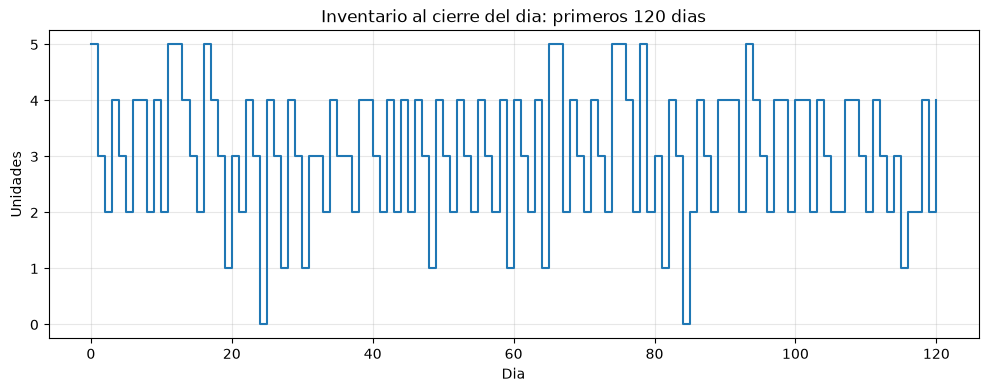

In [9]:
estados_inventario = list(range(6))
demanda_probabilidades = {0: 0.2, 1: 0.5, 2: 0.2, 3: 0.1}
P_inventario = pd.DataFrame(0.0, index=estados_inventario, columns=estados_inventario)
P_inventario.index.name = 'inventario_actual'
P_inventario.columns.name = 'inventario_siguiente'
for inventario in estados_inventario:
    disponible = 5 if inventario <= 2 else inventario
    for demanda, probabilidad in demanda_probabilidades.items():
        siguiente = max(disponible - demanda, 0)
        P_inventario.loc[inventario, siguiente] += probabilidad

print('Matriz teorica P del inventario:')
display(P_inventario)
pi_inventario = distribucion_estacionaria(P_inventario)
estado_inicial_inventario = 5
secuencia_inventario = simular_cadena(P_inventario, estado_inicial_inventario, 10000, 2026)
frecuencias_inventario = secuencia_inventario.iloc[1000:].value_counts(normalize=True).reindex(estados_inventario, fill_value=0)
print('Equilibrio teorico y frecuencias simuladas:')
display(pd.DataFrame({'pi_inventario': pi_inventario, 'frecuencia_simulada': frecuencias_inventario}))
fig, ax = plt.subplots(figsize=(12, 4))
ax.step(secuencia_inventario.index[:121], secuencia_inventario.iloc[:121], where='post')
ax.set_title('Inventario al cierre del dia: primeros 120 dias')
ax.set_xlabel('Dia')
ax.set_ylabel('Unidades')
ax.set_yticks(estados_inventario)
ax.grid(True, alpha=0.3)
plt.show()
